# Executive Summary

## Project Overview

Customer churn is one of the most important business challenges for subscription-based companies. Losing existing customers often costs significantly more than retaining them.

The objective of this project was to develop a machine learning model capable of predicting customer churn and identifying the key factors that influence customer retention.

The project followed a complete machine learning workflow including:

- Data Cleaning and Preparation
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Feature Scaling
- Model Training
- Model Evaluation
- Cross Validation
- Hyperparameter Tuning
- Class Imbalance Handling
- Business Insights Extraction

Several classification algorithms were evaluated and compared, including Logistic Regression, Decision Tree, Random Forest, XGBoost, and Support Vector Machine (SVM).

The final selected model was a Balanced Logistic Regression model, chosen based on its ability to identify a high percentage of churned customers while maintaining acceptable precision.

## Loading The data

---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
pd.set_option('display.max_column', None)

## Data Exploratory Analysis

---

In [2]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [4]:
df.info()

## We have columns that need to be endcoded, and no non values

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
# Churn rate overall
print("Churn rate:")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Churn rate:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.5%
Yes    26.5%
Name: proportion, dtype: str


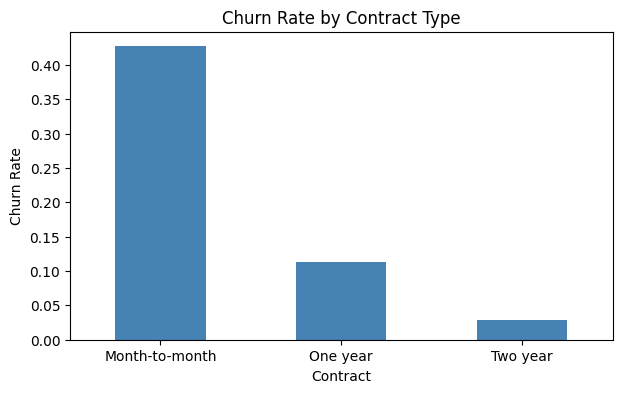

In [6]:
# contract type seems like the most important factor, let's check churn rate for each
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()
contract_churn['Yes'].plot(kind='bar', color='steelblue', figsize=(7, 4))
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate')
plt.xticks(rotation=0)
plt.show()

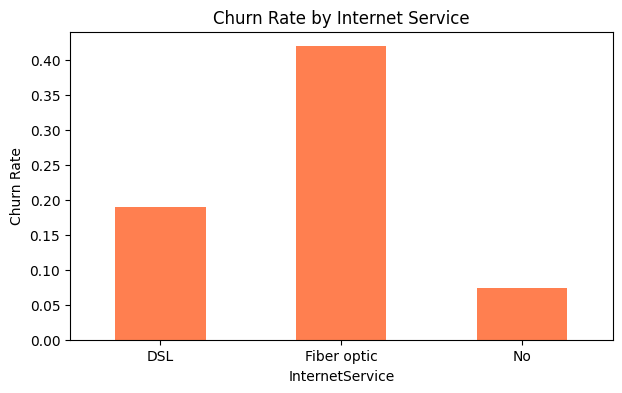

In [7]:
internet_churn = df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack()
internet_churn['Yes'].plot(kind='bar', color='coral', figsize=(7, 4))
plt.title('Churn Rate by Internet Service')
plt.ylabel('Churn Rate')
plt.xticks(rotation=0)
plt.show()

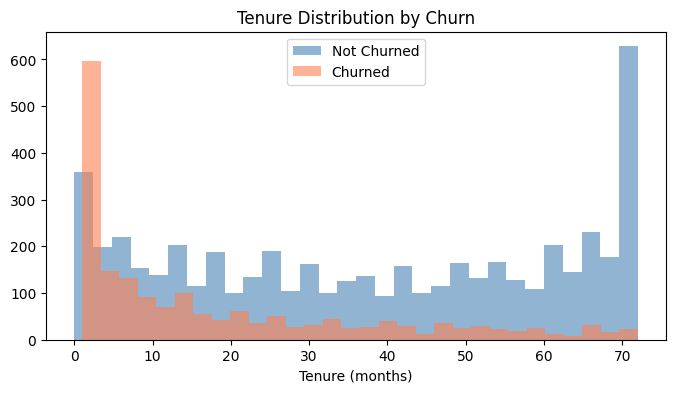

In [8]:
churned = df[df['Churn'] == 'Yes']['tenure']
not_churned = df[df['Churn'] == 'No']['tenure']

plt.figure(figsize=(8, 4))
plt.hist(not_churned, bins=30, alpha=0.6, label='Not Churned', color='steelblue')
plt.hist(churned, bins=30, alpha=0.6, label='Churned', color='coral')
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (months)')
plt.legend()
plt.show()

# clearly churned customers have much lower tenure

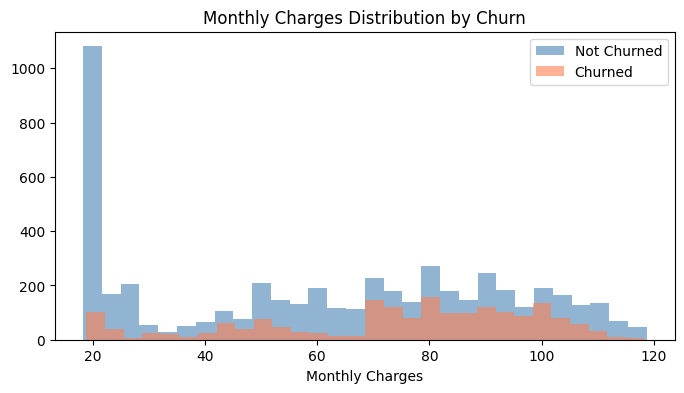

In [9]:
churned_mc = df[df['Churn'] == 'Yes']['MonthlyCharges']
not_churned_mc = df[df['Churn'] == 'No']['MonthlyCharges']

plt.figure(figsize=(8, 4))
plt.hist(not_churned_mc, bins=30, alpha=0.6, label='Not Churned', color='steelblue')
plt.hist(churned_mc, bins=30, alpha=0.6, label='Churned', color='coral')
plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Monthly Charges')
plt.legend()
plt.show()

# churned customers tend to pay more monthly

# Data Cleaning & Transformation
*Encoding Columns*

---

In [10]:
df['gender'].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [11]:
df['gender'] = (df['gender'].str.strip() == 'Female').astype(int)
df['gender'].unique()

array([1, 0])

In [12]:
# Lots of columns are yes or no so let's automate this step 

binary_columns = df[
    ['Partner', 'Dependents', 'PhoneService', 'OnlineSecurity', 
     'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'PaperlessBilling', 'Churn']]

In [13]:
for col in binary_columns:
    print(f'column name: {col} the type {df[col].unique()}')

# Some Columns have not just yes or no so we need to updated the binary columns
    

column name: Partner the type <StringArray>
['Yes', 'No']
Length: 2, dtype: str
column name: Dependents the type <StringArray>
['No', 'Yes']
Length: 2, dtype: str
column name: PhoneService the type <StringArray>
['No', 'Yes']
Length: 2, dtype: str
column name: OnlineSecurity the type <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
column name: OnlineBackup the type <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
column name: DeviceProtection the type <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
column name: TechSupport the type <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
column name: StreamingTV the type <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
column name: StreamingMovies the type <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
column name: PaperlessBilling the type <StringArray>
['Yes', 'No']
Length: 2, dtype: str
column n

In [14]:
binary_columns = df[
    ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']]

In [15]:
for col in binary_columns:
    df[col] = (df[col] == 'Yes').astype(int)

In [16]:
df.info()

## The binary Columns are preprocessed correclty

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   int64  
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   int64  
 4   Dependents        7043 non-null   int64  
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   int64  
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   int64  
 17  Paymen

In [17]:
mask = pd.to_numeric(df['TotalCharges'], errors='coerce').isnull()
df[mask]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,1,0,1,1,0,0,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,1,Bank transfer (automatic),52.55,,0
753,3115-CZMZD,0,0,0,1,0,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,0,Mailed check,20.25,,0
936,5709-LVOEQ,1,0,1,1,0,1,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,0,Mailed check,80.85,,0
1082,4367-NUYAO,0,0,1,1,0,1,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,0,Mailed check,25.75,,0
1340,1371-DWPAZ,1,0,1,1,0,0,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,0,Credit card (automatic),56.05,,0
3331,7644-OMVMY,0,0,1,1,0,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,0,Mailed check,19.85,,0
3826,3213-VVOLG,0,0,1,1,0,1,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,0,Mailed check,25.35,,0
4380,2520-SGTTA,1,0,1,1,0,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,0,Mailed check,20.00,,0
5218,2923-ARZLG,0,0,1,1,0,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,1,Mailed check,19.70,,0
6670,4075-WKNIU,1,0,1,1,0,1,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,0,Mailed check,73.35,,0


In [18]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors= 'coerce')

In [19]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [20]:
mask = df['TotalCharges'].isnull()
df[mask]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,1,0,1,1,0,0,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,1,Bank transfer (automatic),52.55,NaN,0
753,3115-CZMZD,0,0,0,1,0,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,0,Mailed check,20.25,NaN,0
936,5709-LVOEQ,1,0,1,1,0,1,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,0,Mailed check,80.85,NaN,0
1082,4367-NUYAO,0,0,1,1,0,1,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,0,Mailed check,25.75,NaN,0
1340,1371-DWPAZ,1,0,1,1,0,0,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,0,Credit card (automatic),56.05,NaN,0
3331,7644-OMVMY,0,0,1,1,0,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,0,Mailed check,19.85,NaN,0
3826,3213-VVOLG,0,0,1,1,0,1,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,0,Mailed check,25.35,NaN,0
4380,2520-SGTTA,1,0,1,1,0,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,0,Mailed check,20.00,NaN,0
5218,2923-ARZLG,0,0,1,1,0,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,1,Mailed check,19.70,NaN,0
6670,4075-WKNIU,1,0,1,1,0,1,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,0,Mailed check,73.35,NaN,0


In [21]:
## Droping the empty rows 

df.dropna(inplace=True)

In [22]:
df['TotalCharges'].apply(type).value_counts()

TotalCharges
<class 'float'>    7032
Name: count, dtype: int64

In [23]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   int64  
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   int64  
 4   Dependents        7032 non-null   int64  
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   int64  
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   int64  
 17  PaymentMeth

In [24]:
## Checking duplicates 

df.duplicated(subset='customerID').sum()
## No duplicates 

np.int64(0)

# Encoding Columns with multiple classes

---

In [25]:
categorical_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity','OnlineBackup', 'DeviceProtection',
                        'TechSupport',   'StreamingTV', 'StreamingMovies', 'Contract','PaymentMethod']

In [26]:
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [27]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   customerID                             7032 non-null   str    
 1   gender                                 7032 non-null   int64  
 2   SeniorCitizen                          7032 non-null   int64  
 3   Partner                                7032 non-null   int64  
 4   Dependents                             7032 non-null   int64  
 5   tenure                                 7032 non-null   int64  
 6   PhoneService                           7032 non-null   int64  
 7   PaperlessBilling                       7032 non-null   int64  
 8   MonthlyCharges                         7032 non-null   float64
 9   TotalCharges                           7032 non-null   float64
 10  Churn                                  7032 non-null   int64  
 11  MultipleLines_No pho

# Feature Selection

---

In [28]:
df.drop('customerID', axis=1, inplace=True)

# Droping Id column as it is not useful at all

In [29]:
# Chaning bool to int

bool_columns = df.select_dtypes(include='bool').columns

df[bool_columns] = df[bool_columns].astype(int)

In [30]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7032 non-null   int64  
 10  MultipleLines_No phone service         7032 non-null   int64  
 11  MultipleLines_Yes   

In [31]:
X = df.drop('Churn', axis=1)
y = df['Churn']

# Train/Test Split

---

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Base Model : LogisticRegression

---

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score


# Scaling

---

In [34]:
# Feature Scaling 

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [35]:
# Model Trainig

LR = LogisticRegression()
LR.fit(X_train, y_train)

y_prediction = LR.predict(X_test)


# Evaluation

----

In [36]:
# Model Evaluation

accuracy = accuracy_score(y_test, y_prediction)
precision = precision_score(y_test, y_prediction)
recall = recall_score(y_test, y_prediction)
f1 = f1_score(y_test, y_prediction)
CM = confusion_matrix(y_test, y_prediction)


print(f'Accuracy : {accuracy}')
print(f'Precision : {precision}')
print(f'Recall : {recall}')
print(f'F1 : {f1}')
print(f'Confusion Matrix : {CM}')



# For Base Model Logistic Regression we can see that the results are not the wanted ones , the accuracy is acceptable with 0.78
# However the Precision is bad 0.62 as well as the recall 0.51
# Precision 0.61 the model ability to classify churn customer correctly 
# Recall 0.51 the nodel ability to detect churn customer out of all the true churn customers 
# The Confustion Matrix shows that clearly where: 
# TN are 915 The model succefully predicted 915 as churn customers 
# FP are 118 The model predicted 118 as not churned customers when they are churned
# FN are 181 the model predicted 181 Customers as churned when they are not
# TP are 193  model secussfully predicted 193 as non churned customers


#[[TN FP]
 #[FN TP]]

Accuracy : 0.7874911158493249
Precision : 0.6205787781350482
Recall : 0.516042780748663
F1 : 0.5635036496350365
Confusion Matrix : [[915 118]
 [181 193]]


# Visualizion 

---

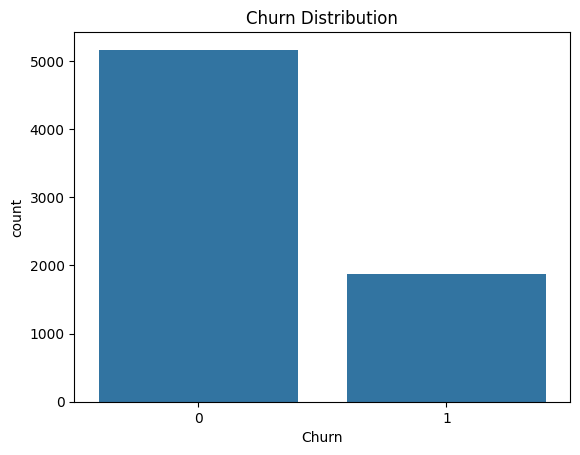

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

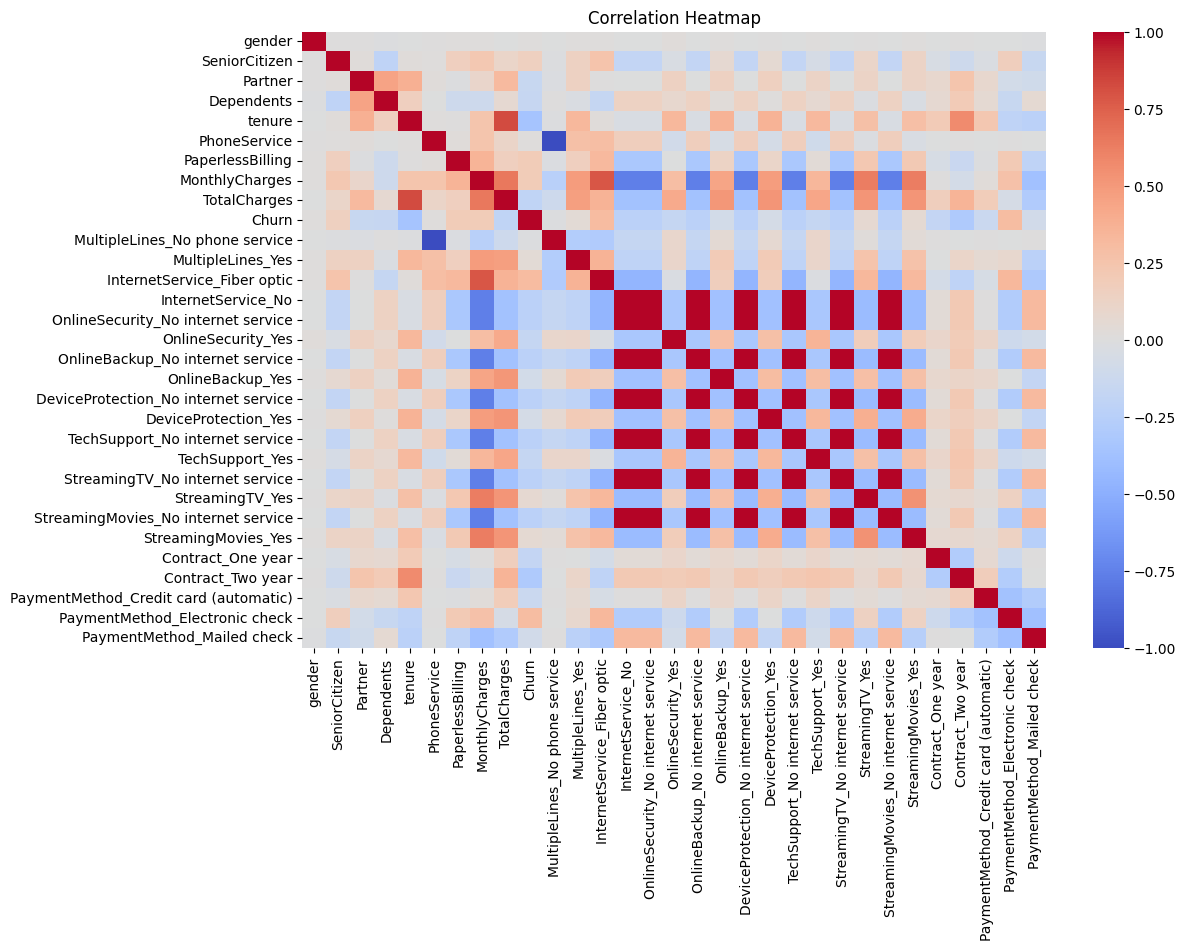

In [38]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

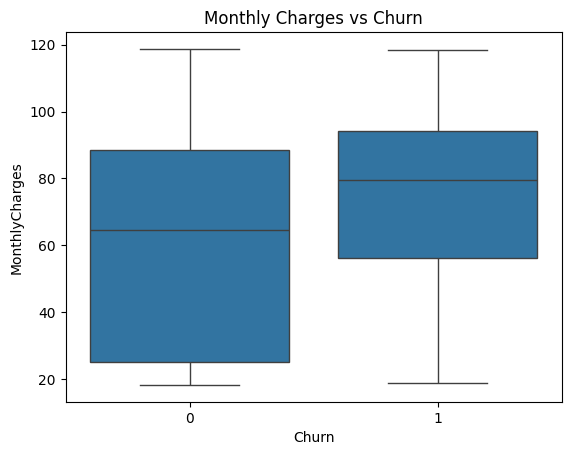

In [39]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.show()

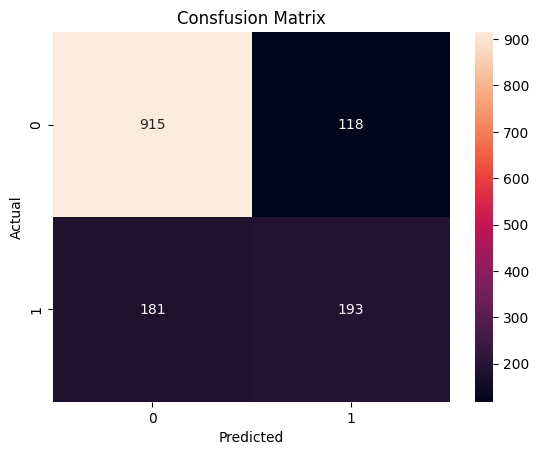

In [40]:
sns.heatmap(CM, annot=True, fmt='d')
plt.title('Consfusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


# Compare Multiple Models

---

In [41]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier


In [42]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier()
}

In [43]:
results = []


for name, model in models.items():
    model.fit(X_train, y_train)
    predction = model.predict(X_test)
    accuracy = accuracy_score(y_test, predction)
    precision = precision_score(y_test, predction)
    recall = recall_score(y_test, predction)
    F1 =  f1_score(y_test, predction)
    
    results.append([name, accuracy, precision, recall, F1])

In [44]:
results = pd.DataFrame(results)

In [45]:
results.rename(columns={  0:"Model", 1: "Accuracy", 2 : 'Precision', 3 : 'Recall', 4 : "F1"}, inplace=True)

In [46]:
results

,Model,Accuracy,Precision,Recall,F1
0,Decision Tree,0.719261,0.474453,0.521390,0.496815
1,Random Forest,0.786070,0.628975,0.475936,0.541857
2,KNN,0.751955,0.535211,0.508021,0.521262


## Cross Validation on the best Model

In [47]:
from sklearn.model_selection import cross_val_score

In [48]:
cross_val_score(LogisticRegression(), X_train, y_train, cv= 5, scoring= 'f1')

# the logistic regression models shows stability across different training samples 

array([0.62773723, 0.60759494, 0.571949  , 0.59139785, 0.63405797])

In [49]:
cross_val_score(LogisticRegression(), X_train, y_train, cv= 5, scoring= 'f1').mean()
# The mean f1 score would be 0.60

np.float64(0.6065473963283196)

## Hyperparameter Tuning

---

In [50]:
# Random Forst 

from sklearn.model_selection import GridSearchCV


param_grid = {'n_estimators': [100,200,300],
              'max_depth' : [5,10,15],
              'min_samples_split' : [2,5,10] 
              }


Random_Forst_tuned = GridSearchCV(estimator=RandomForestClassifier(random_state=42), 
                                  param_grid=param_grid,
                                  cv=5,
                                  scoring='f1')

In [51]:
Random_Forst_tuned.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >

In [52]:
Random_Forst_tuned.best_params_

{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}

In [53]:
Random_Forst_tuned.best_score_

np.float64(0.5960075675276733)

In [54]:
best_random_forest = Random_Forst_tuned.best_estimator_

In [55]:
y_pred = best_random_forest.predict(X_test)

In [56]:
result = []

metrics = {
'accuracy' : accuracy_score(y_test, y_pred),
'precision' : precision_score(y_test, y_pred),
'recall' : recall_score(y_test, y_pred),
'f1_score' : f1_score(y_test, y_pred)
}
for name, model in metrics.items():
    print(f'{name} : {model}')

accuracy : 0.7938877043354655
precision : 0.6555555555555556
recall : 0.4732620320855615
f1_score : 0.5496894409937888


# Comparsion of The Best Models Performance

---

In [57]:
models = {"DicisionTree" : DecisionTreeClassifier(random_state=42),
          "Random_Forest" : RandomForestClassifier(random_state=42),
          "Tuned_Random_Forest" : best_random_forest}

In [58]:
result_ = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    result_.append([ name, round(accuracy,3), round(precision,3), round(recall,3), round(f1, 3)])

In [59]:
result_ = pd.DataFrame(result_)
result_.rename(columns={0 : 'Model', 1 : 'Accuracy', 2 : 'Precision' , 3 : 'Recall', 4: 'F1' },  inplace=True)



# From the below table we can see three things 
# First the baseline mode has the highest recall but lowest precision and accuracy in case of recall it is the best 
# Second the tuning for random forest impacted the the accuracy and precision and even the difference in F1 score is noticable it is not big there's a progress 
# These results shows that parameters tuning and CV impacted the overall performance for a model like Random Forest However we still haven't imporved the recall yet
# Which is very important as after all we assessing the recall for churned customers which is a small percentage in general
# we need to try different models or apply Feature engineering

The Tuned Random Forest achieved the highest overall F1 score (0.55) and the highest precision (0.656).

However, recall remained relatively low (0.473), indicating that the model still misses a considerable number of churned customers.

This suggests that hyperparameter tuning alone is not sufficient, and further improvements may require:
- Feature engineering
- Additional models (XGBoost, SVM)
- Class imbalance techniques
- Threshold tuning

# XGBoost Model

---

In [60]:
from xgboost import XGBClassifier

In [61]:
xgb = XGBClassifier(random_state=42)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)


In [62]:
metrics = {"Acccuary" : accuracy_score(y_test, y_pred),
           'Precision' : precision_score(y_test, y_pred),
           'Recall' : recall_score(y_test, y_pred),
           'F1' : f1_score(y_test, y_pred)}

for name, metric in metrics.items():
    print(f'{name} : {metric}')

Acccuary : 0.7739872068230277
Precision : 0.5886075949367089
Recall : 0.49732620320855614
F1 : 0.5391304347826087


In [63]:
results = []

models = {'LogisticeRegression' : LogisticRegression(random_state=42),
          'Random_Forest_Tuned' : best_random_forest,
          'XBGoost' : XGBClassifier(random_state=42)}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, accuracy, precision, recall, f1])

In [64]:
results = pd.DataFrame(results)
results.rename(columns={0 : 'Model', 1: 'Accuracy', 2 : 'Precision', 3 : "Recall", 4 : 'F1' },  inplace=True)

# SVM Model

---

In [65]:
from sklearn.svm import SVC

In [66]:
results = []

models = {
    'LogisticRegression' : LogisticRegression(random_state=42),
    'Random_Forest_Tuned' : best_random_forest,
    'XGBoost' : XGBClassifier(random_state=42),
    'SVM' : SVC(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, accuracy, precision, recall, f1])

In [67]:
results = pd.DataFrame(results)
results.rename(columns={0 : 'Model', 1: 'Accuracy', 2 : 'Precision', 3 : "Recall", 4 : 'F1' },  inplace=True)

*It seems cleary that logistice Regression is still beating other models which means either the data is too linear or we need to work on Feature importance rather than Trying different models*

# Feature Importance

---

In [68]:
feature_importance = pd.DataFrame({
    'Feature' : X.columns,
    'Importance' : best_random_forest.feature_importances_
})

feature_importance.sort_values(by='Importance',
                               ascending=False,
                               inplace=True)

feature_importance.head(10)

,Feature,Importance
4,tenure,0.189392
8,TotalCharges,0.168276
7,MonthlyCharges,0.118137
11,InternetService_Fiber optic,0.070589
26,Contract_Two year,0.055319
28,PaymentMethod_Electronic check,0.053899
25,Contract_One year,0.036791
14,OnlineSecurity_Yes,0.029438
20,TechSupport_Yes,0.028488
6,PaperlessBilling,0.019451


# Feature Engineering

Feature engineering was performed to create additional information that may help the models identify churn patterns.

A new feature called **AvgMonthlySpend** was created using:

AvgMonthlySpend = TotalCharges / Tenure

This feature represents the average amount spent by a customer during their relationship with the company and was introduced to better capture spending behavior.

In [69]:
# First Attempt adding Avgerage Monthly Spend

X['AvgMonthlySpend'] = X['TotalCharges'] / X["tenure"]

In [70]:
(X['tenure'] == 0).sum()
# No infinite numbers

np.int64(0)

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [72]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [73]:
results = []

models = {'LogisticRegression' : LogisticRegression(random_state=42),
          'Tuned_Random_Forest' : best_random_forest,
          'XGBoost' : XGBClassifier(random_state=42)}


for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, accuracy, precision, recall, f1])



In [74]:
results = pd.DataFrame(results)
results.rename(columns={0 : 'Model', 1: 'Accuracy', 2 : 'Precision', 3 : "Recall", 4 : 'F1' },  inplace=True)

# Class Imbalance Analysis

Before selecting a final model, the target variable distribution was examined.

The analysis revealed that approximately:

- 73% of customers did not churn
- 27% of customers churned

This imbalance can negatively impact model performance because many algorithms tend to favor the majority class.

As a result, additional techniques were explored to improve the model's ability to detect churned customers.

In [75]:
# The behavior of classes and the results of different models suggest that
# The classes are probably imbalanced

df['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [76]:
df['Churn'].value_counts(normalize=True) * 100

Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64

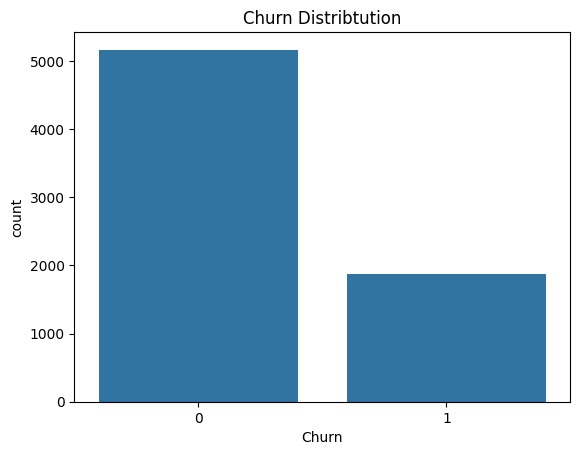

In [77]:
sns.countplot(x="Churn", data=df)
plt.title('Churn Distribtution')
plt.show()


# The imbalance exists, 
# but it is not severe enough to fully explain the mediocre recall

## Do churners actually look different from non-churners?

---

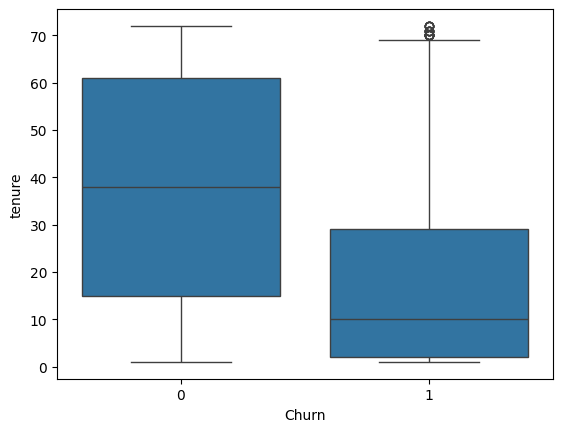

In [78]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.show()

# Customers who stay tend to have been with the company much longer.
# New customers leave more often.
# Loyal customers stay.

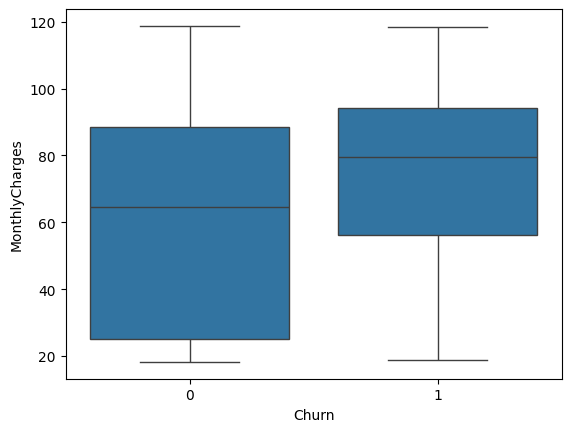

In [79]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

# Customers paying more every month are more likely to churn.

# Expensive plans create dissatisfaction.
# Customers may find cheaper competitors.

<Axes: xlabel='Churn', ylabel='TotalCharges'>

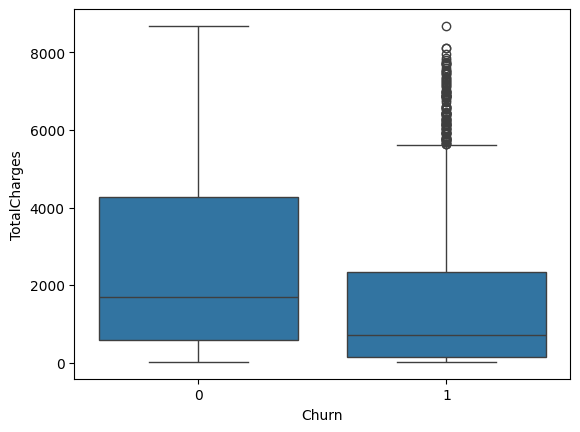

In [80]:
sns.boxplot(x='Churn', y='TotalCharges', data=df)

*The features contain useful information, but they do not perfectly separate churners from non-churners.*

**Churn behavior is partially predictable through tenure and charges, but substantial overlap between churners and non-churners limits model performance.**

---

# Handling Class Imbalance

To improve churn detection, the parameter:

class_weight = 'balanced'

was applied.

This technique increases the penalty associated with misclassifying churned customers during training.

As a result, the model becomes more sensitive to the minority class and improves its ability to identify customers at risk of leaving.

The expected trade-off is a decrease in Precision accompanied by a significant improvement in Recall.

In [81]:
LogisticRegression_balanced = LogisticRegression(random_state=42, class_weight='balanced')

In [82]:
LogisticRegression_balanced.fit(X_train, y_train)
y_pred = LogisticRegression_balanced.predict(X_test)

In [83]:
metrics = {'Accuarcy' : accuracy_score(y_test, y_pred),
           'Precision' : precision_score(y_test, y_pred),
           'Recall' : recall_score(y_test, y_pred),
           'F1' : f1_score(y_test, y_pred)}

for name, metric in metrics.items():
    print(f'{name}: {round(metric,3)}')


# Using weight clase got us the recall 0.79 which is great 
# however the precision went down as expected 
# the F1 score went up too 



Accuarcy: 0.731
Precision: 0.497
Recall: 0.791
F1: 0.61


**The gain in Recall was larger than the loss in Precision.**

Applying class_weight='balanced' significantly improved Recall from 0.51 to 0.79, indicating the model became much better at identifying churners. Although Precision decreased from 0.62 to 0.50, the overall F1 score improved from 0.56 to 0.61. Since the business objective is to identify as many potential churners as possible, the balanced Logistic Regression model provides a better trade-off than the original model.

---

# Comparison on of class weight on different models 

---

In [84]:
param_grid= {'n_estimators' : [100,200,300],
             'max_depth' : [5,10,15],
             'min_samples_split' : [2,5,10]}

Random_Forst_tuned_balanced = GridSearchCV(estimator=RandomForestClassifier(random_state=42, class_weight='balanced'),
                                           param_grid=param_grid,
                                           cv=5,
                                           scoring='f1')

In [85]:
Random_Forst_tuned_balanced.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >

In [86]:
Random_Forst_tuned_balanced.best_params_

{'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}

In [87]:
Random_Forst_tuned_balanced.best_score_

np.float64(0.6433806190503508)

In [88]:
Best_Random_Forst_tuned_balanced = Random_Forst_tuned_balanced.best_estimator_

In [89]:
results = []

models = { 'LogisticRegression' : LogisticRegression(random_state=42, class_weight='balanced'),
           'Decision Tree' :DecisionTreeClassifier(random_state=42, class_weight='balanced'),
          'Random Forest' : RandomForestClassifier(random_state=42, class_weight='balanced'),
          'XGBoost' : XGBClassifier(random_state=42, scale_pos_weight=2.76,),
          'Tuned/Balanced Random Forest' : Best_Random_Forst_tuned_balanced
          }

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, accuracy, precision, recall, f1])
    



In [90]:
results = pd.DataFrame(results)
results.rename(columns={0 : 'Model', 1: 'Accuracy', 2 : 'Precision', 3 : "Recall", 4 : 'F1' })

,Model,Accuracy,Precision,Recall,F1
0,LogisticRegression,0.731343,0.496644,0.791444,0.610309
1,Decision Tree,0.735608,0.502577,0.521390,0.511811
2,Random Forest,0.779673,0.617647,0.449198,0.520124
3,XGBoost,0.747690,0.520697,0.639037,0.573830
4,Tuned/Balanced Random Forest,0.753376,0.526946,0.705882,0.603429


# Business Conclusion

---

Multiple classification models were evaluated for churn prediction. **Logistic Regression, Decision Tree, Random Forest, Tuned Random Forest, and XGBoost** were compared using **Accuracy, Precision, Recall, and F1 Score**. Due to class imbalance, class weights were introduced. The balanced Logistic Regression model achieved the highest **F1 score (0.61) and Recall (0.79)**, making it the preferred model for identifying potential churners. Results indicate that handling class imbalance had a greater impact on performance than increasing model complexity.

----

# Confusion Matrix (Winning Model)

---

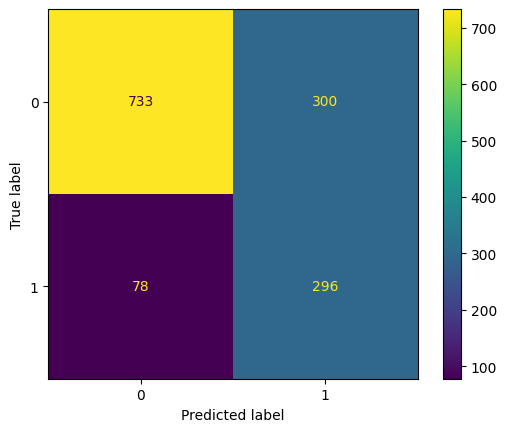

In [91]:
from sklearn.metrics import ConfusionMatrixDisplay

LogisticRegression_balanced = LogisticRegression(random_state=42, class_weight='balanced')

LogisticRegression_balanced.fit(X_train, y_train)

y_pred = LogisticRegression_balanced.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm).plot()
plt.show()

## Confusion Matrix Analysis

The confusion matrix provides a detailed view of model performance.

The model correctly identified:

- 733 customers who stayed
- 296 customers who churned

The model missed:

- 78 actual churned customers

The model incorrectly flagged:

- 300 customers as churners when they actually stayed

Although the model generates some false positives, this behavior is acceptable because the business objective is to identify as many potential churners as possible before they leave.

Missing a churned customer is generally more costly than contacting a customer who was not actually planning to leave.

---

# ROC-AUC / Precision-Recall-Analysis

---

In [92]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay

y_prob = LogisticRegression_balanced.predict_proba(X_test)[:,1]

roc_auc_score(y_test, y_prob)

0.8316051581241491

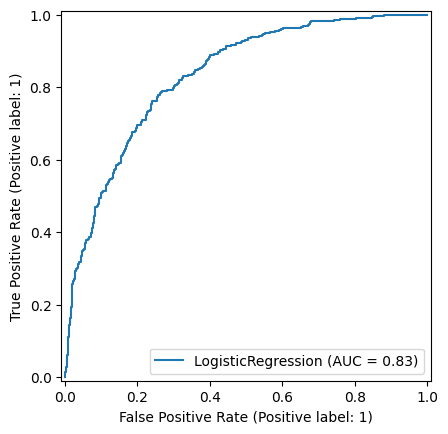

In [93]:
RocCurveDisplay.from_estimator(
    LogisticRegression_balanced, X_test, y_test
)

plt.show()

## ROC-AUC Analysis

The model achieved an ROC-AUC score of 0.83.

ROC-AUC measures the model's ability to distinguish between churned and non-churned customers across all classification thresholds.

An AUC score of 0.83 indicates strong discriminatory power and demonstrates that the model can effectively separate high-risk customers from low-risk customers.

This result suggests that the model captures meaningful churn patterns within the dataset.

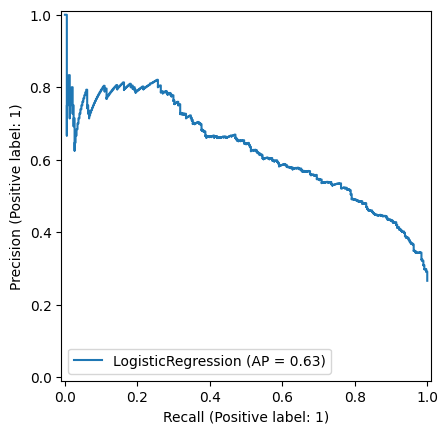

In [94]:
PrecisionRecallDisplay.from_estimator(
    LogisticRegression_balanced,
    X_test,
    y_test
)
plt.show()

## Precision-Recall Analysis

Because customer churn is an imbalanced classification problem, Precision and Recall are more informative than Accuracy alone.

The model achieved a Recall of approximately 79%, meaning it successfully identified the majority of customers who eventually churned.

Although Precision decreased compared to the original model, the increase in Recall aligns with the business objective of maximizing churn detection.

This trade-off is acceptable because retaining a potential churner often outweighs the cost of contacting a customer who would have stayed.

----

# Logistic Regression Coefficients

---

In [95]:
coef_df = pd.DataFrame({
    'Feature' : X.columns,
    'Coefficient' : LogisticRegression_balanced.coef_[0]
})

coef_df.sort_values(by='Coefficient', ascending=False).head(10)

,Feature,Coefficient
11,InternetService_Fiber optic,0.725004
8,TotalCharges,0.655722
24,StreamingMovies_Yes,0.258766
22,StreamingTV_Yes,0.253815
10,MultipleLines_Yes,0.159708
28,PaymentMethod_Electronic check,0.139451
6,PaperlessBilling,0.120714
1,SeniorCitizen,0.095253
18,DeviceProtection_Yes,0.049093
30,AvgMonthlySpend,0.026073


In [96]:
coef_df.sort_values(by='Coefficient').head(10)

,Feature,Coefficient
4,tenure,-1.351857
7,MonthlyCharges,-0.873985
26,Contract_Two year,-0.605168
25,Contract_One year,-0.328400
14,OnlineSecurity_Yes,-0.128864
20,TechSupport_Yes,-0.115036
3,Dependents,-0.099552
13,OnlineSecurity_No internet service,-0.085538
17,DeviceProtection_No internet service,-0.085538
21,StreamingTV_No internet service,-0.085538


# Business Insights

The analysis identified several important factors associated with customer churn.

### Factors Increasing Churn Risk

- Fiber Optic Internet Service
- Electronic Check Payment Method
- Paperless Billing
- Streaming Services
- Higher Total Charges

### Factors Reducing Churn Risk

- Longer Customer Tenure
- One-Year Contracts
- Two-Year Contracts
- Online Security Services
- Technical Support Services
- Customers with Dependents

The strongest retention factor identified by the model was customer tenure, indicating that customers become significantly less likely to churn as their relationship with the company grows.

----

# Final Model Performance

## Selected Model

After comparing multiple machine learning algorithms and addressing class imbalance, the final selected model was:

### Balanced Logistic Regression

### Performance Metrics

| Metric | Score |
|----------|----------|
| Accuracy | 73% |
| Precision | 50% |
| Recall | 79% |
| F1 Score | 61% |
| ROC-AUC | 0.83 |

The model successfully identified approximately 79% of churned customers, making it highly suitable for customer retention initiatives where detecting potential churners is more important than minimizing false alarms.

---

# Business Recommendations

Based on the findings of this analysis, the following recommendations are proposed:

### 1. Focus on New Customers

Customers with shorter tenure exhibit the highest churn risk. Early retention initiatives should be prioritized during the first months of the customer lifecycle.

### 2. Promote Long-Term Contracts

Customers enrolled in one-year and two-year contracts are significantly less likely to churn than month-to-month customers.

### 3. Investigate Fiber Optic Customer Churn

Fiber Optic customers demonstrated a higher likelihood of churn. Additional investigation may reveal service quality, pricing, or satisfaction issues.

### 4. Promote Value-Added Services

Online Security and Technical Support services appear to increase customer retention and should be actively promoted.

### 5. Deploy Predictive Retention Campaigns

The model can be integrated into customer retention workflows to identify high-risk customers and enable proactive intervention.

---
# Conclusion

This project successfully developed an end-to-end machine learning solution for customer churn prediction.

Multiple machine learning algorithms were trained, evaluated, and compared using a variety of performance metrics. Additional improvements were achieved through feature engineering, cross validation, hyperparameter tuning, and class imbalance handling.

The final selected model was a Balanced Logistic Regression model that achieved:

- Accuracy: 73%
- Precision: 50%
- Recall: 79%
- F1 Score: 61%
- ROC-AUC: 0.83

The model demonstrated strong ability to identify customers at risk of churn while providing valuable business insights regarding the factors that influence customer retention.

The results of this analysis can support data-driven retention strategies and help reduce customer loss through targeted interventions.

---